Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

Import Dataset

In [2]:
df = pd.read_csv("data.csv", delimiter='\t', low_memory=False)
df.head()

,Unnamed: 0,date,id,size_grp,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,ret,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,53170,9/30/1962,33814,mega,-0.4108911,0.3436155,0.0,-0.290922,-0.44744524,0.24796748,...,0.27476254,0.0,0.17842606,0.033875,0.0,0.017612524,NaN,NaN,NaN,NaN
1,53907,10/31/1962,33814,mega,-0.41374046,0.33333334,0.0,-0.281893,-0.44759825,0.23134328,...,0.21059783,0.0,0.13586956,0.094301,0.0,0.1242307722568512,NaN,NaN,NaN,NaN
2,54659,11/30/1962,33814,mega,-0.4017857,0.33169705,0.0,-0.297587,-0.4487909,0.2214854,...,0.1679947,0.0,0.1374502,0.111406,0.0,-0.01208981,NaN,NaN,NaN,NaN
3,55425,12/31/1962,33814,mega,-0.37068966,0.32225236,0.0,-0.309585,-0.4398085,0.21501926,...,0.12516046,0.0,0.1097561,0.194480,0.11369509,0.087412588,NaN,NaN,NaN,NaN
4,56207,1/31/1963,33814,mega,-0.36795145,0.32456142,0.0,-0.308729,-0.44189188,0.21082802,...,0.035714287,0.0,0.10841837,0.149682,0.08151476,-0.021864953,NaN,NaN,NaN,NaN


Clean Dataset

In [3]:
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
df.dropna(inplace=True)
date = df['date']
print(date.shape)
df.drop(columns=['date'], inplace=True)

df.dropna(inplace=True)
print(df.shape)

(122634,)
(122634, 124)


Export Dataset back 

In [ ]:
df.to_csv("cleaned_data.csv", index=False)
date.to_csv("cleaned_date.csv", index=False)

Lasso regression using Sklearn

Lasso Regression MSE (alpha=1.0): 0.0104


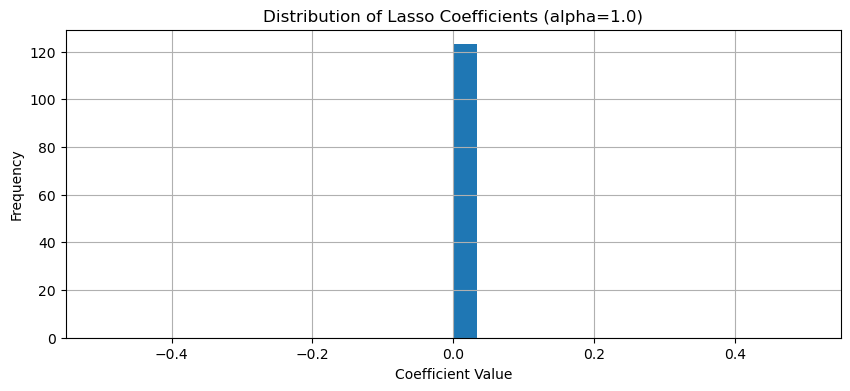

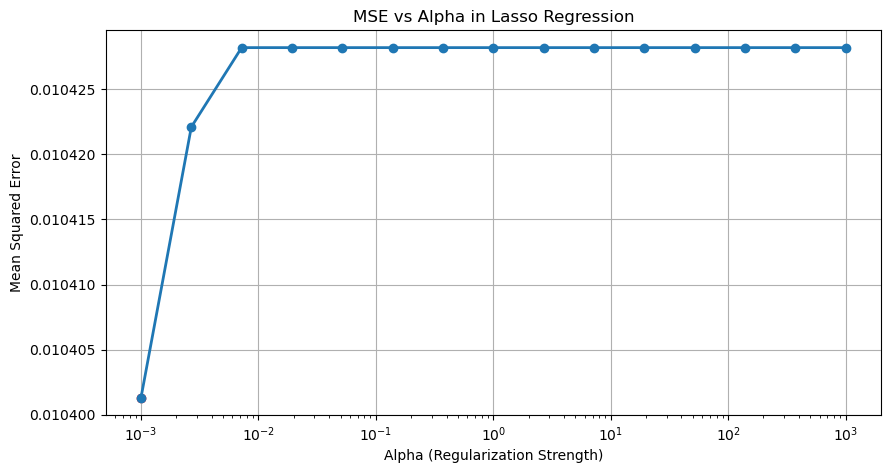

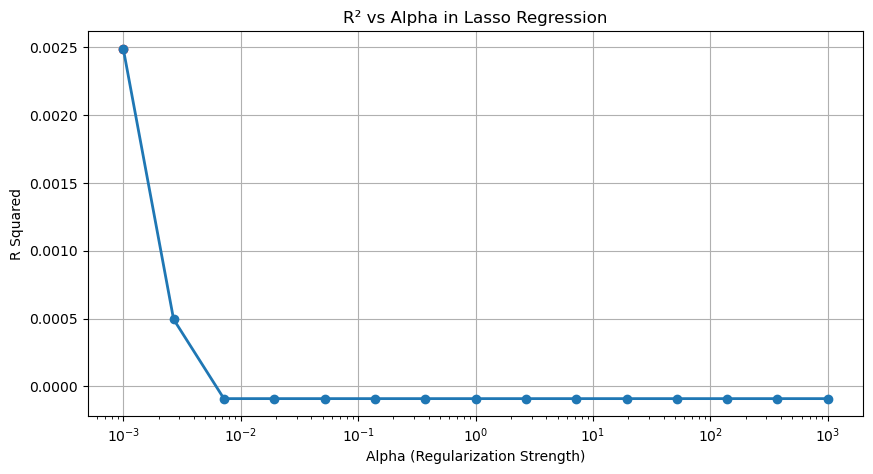

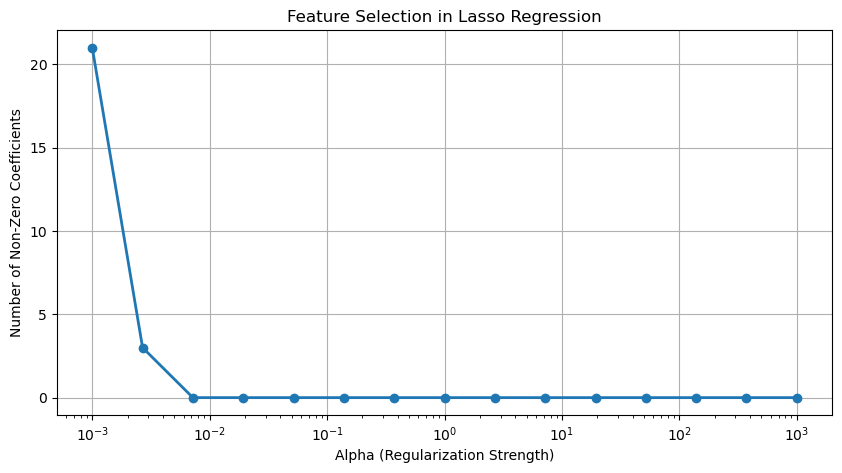

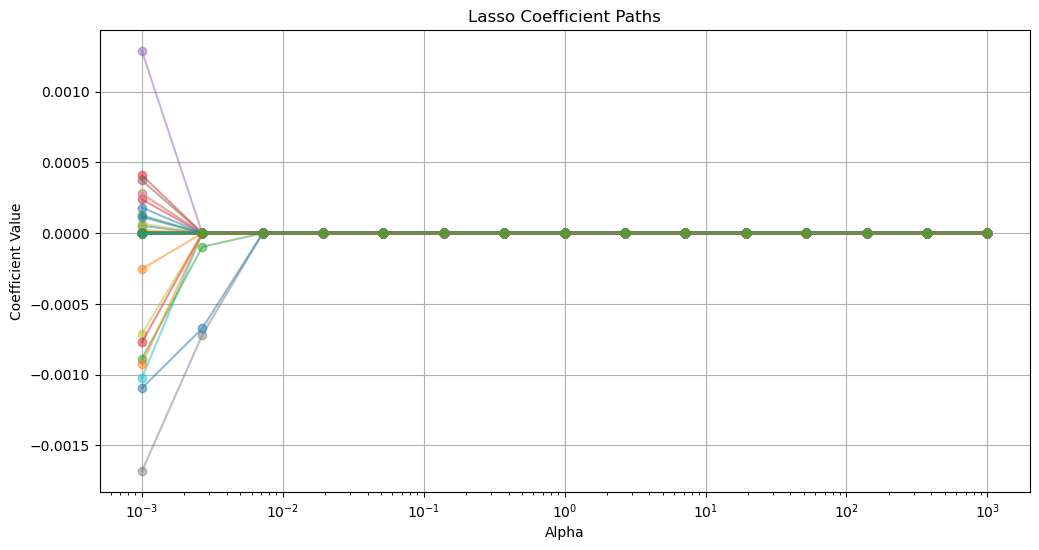

In [4]:
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)
y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lasso regression with alpha=1.0
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

# Compute and print MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Lasso Regression MSE (alpha=1.0): {mse:.4f}")

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(lasso.coef_, bins=30)
plt.title("Distribution of Lasso Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Analyze effect of varying alpha
alphas = np.logspace(-3, 3, 15)
coefs = []
mses = []
rs = []
nonzero_coefs = []  # Track number of non-zero coefficients

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)
    y_pred = model.predict(X_test)
    mses.append(mean_squared_error(y_test, y_pred))
    rs.append(r2_score(y_test, y_pred))
    nonzero_coefs.append(np.sum(model.coef_ != 0))  # Count non-zero coefficients

best_idx_ms = np.argmin(mses)
best_idx_rs = np.argmax(rs)  # Note: For R², we want maximum, not minimum
best_alpha_ms = alphas[best_idx_ms]
best_mse = mses[best_idx_ms]
best_alpha_rs = alphas[best_idx_rs]
best_rs = rs[best_idx_rs]

def plot(losses, best_loss, name_loss, abbrev, best_alpha, alphas):
    plt.figure(figsize=(10, 5))
    plt.plot(alphas, losses, marker='o', linewidth=2)
    plt.xscale("log")
    plt.xlabel("Alpha (Regularization Strength)")
    plt.ylabel(name_loss)
    plt.title(abbrev + " vs Alpha in Lasso Regression")
    plt.grid(True)
    # Turn off scientific notation
    plt.ticklabel_format(style='plain', axis='y')
    
    # Annotate best point
    plt.scatter(best_alpha, best_loss, color='red')
    
    plt.show()

plot(mses, best_mse, 'Mean Squared Error', 'MSE', best_alpha_ms, alphas)
plot(rs, best_rs, 'R Squared', 'R²', best_alpha_rs, alphas)

# Additional plot for feature selection behavior
plt.figure(figsize=(10, 5))
plt.plot(alphas, nonzero_coefs, marker='o', linewidth=2)
plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Feature Selection in Lasso Regression")
plt.grid(True)
plt.show()

# Plot coefficient paths
plt.figure(figsize=(12, 6))
for i in range(len(coefs[0])):
    plt.plot(alphas, [coefs[j][i] for j in range(len(alphas))], 'o-', alpha=0.5)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.grid(True)
plt.show()